In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/transactions_raw.csv')

print("Shape:", df.shape)
print("\nStatus values:", df['status'].unique())
print("Failure reasons:", df['failure_reason'].unique())
print("Channels:", df['payment_channel'].unique())
print("Banks:", df['bank_name'].unique())
df.head(3)

Shape: (10000, 14)

Status values: ['Failed' 'Success']
Failure reasons: ['insufficient_funds' 'none' 'network_failure' 'duplicate_txn'
 'outside_neft_hours' 'wrong_pin' 'fraud_blocked' 'wrong_ifsc'
 'account_blocked' 'bank_server_timeout' 'invalid_account']
Channels: ['UPI' 'Card' 'RTGS' 'NEFT' 'Wallet']
Banks: ['ICICI' 'Kotak' 'HDFC' 'SBI' 'Axis']


,transaction_id,timestamp,payment_channel,bank_name,amount,status,failure_reason,hour,day_of_month,month,day_of_week,is_failed,is_night_window,is_salary_window
0,TXN000001,2024-03-03 01:58:20,UPI,ICICI,12320.10,Failed,insufficient_funds,1,3,3,Sunday,1,1,0
1,TXN000002,2024-03-06 16:49:26,Card,Kotak,4438.25,Success,none,16,6,3,Wednesday,0,0,0
2,TXN000003,2024-01-03 21:25:57,UPI,HDFC,25317.23,Failed,network_failure,21,3,1,Wednesday,1,0,0


In [2]:
df['status'] = df['status'].str.lower().str.strip()

# Quick sanity check
print("Status counts:\n", df['status'].value_counts())
print("\nChannel counts:\n", df['payment_channel'].value_counts())
print("\nBank counts:\n",    df['bank_name'].value_counts())

Status counts:
 status
success    7663
failed     2337
Name: count, dtype: int64

Channel counts:
 payment_channel
UPI       3470
NEFT      2500
Card      2017
RTGS      1010
Wallet    1003
Name: count, dtype: int64

Bank counts:
 bank_name
Axis     2030
SBI      2023
Kotak    2005
HDFC     1981
ICICI    1961
Name: count, dtype: int64


Assign Severity Score to Each Row

In [3]:
# failure_reason → severity number
# 3 = worst  (bank/gateway refused the transaction)
# 2 = medium  (network/timeout — infrastructure issue)  
# 1 = mild    (user mistake — wrong pin, low balance)

def classify_severity(reason):
    if pd.isna(reason):
        return 0   # successful txn — no error
    r = str(reason).lower()
    
    # ── Severe: bank/gateway side ──────────────────────────
    if any(k in r for k in [
        'gateway', 'server', 'bank', 'acquirer', 
        'issuer', 'system', 'technical', 'processing'
    ]):
        return 3
    
    # ── Medium: infrastructure/network ────────────────────
    elif any(k in r for k in [
        'timeout', 'network', 'connection', 
        'unavailable', 'declined', 'limit'
    ]):
        return 2
    
    # ── Mild: user-side error ──────────────────────────────
    else:  # insufficient funds, wrong pin, cancelled etc.
        return 1

df['severity_score'] = df['failure_reason'].apply(classify_severity)

# Verify mapping
print(df[['failure_reason', 'severity_score']].drop_duplicates().sort_values('severity_score', ascending=False))

         failure_reason  severity_score
65  bank_server_timeout               3
2       network_failure               2
0    insufficient_funds               1
1                  none               1
4         duplicate_txn               1
19            wrong_pin               1
15   outside_neft_hours               1
22        fraud_blocked               1
27           wrong_ifsc               1
41      account_blocked               1
76      invalid_account               1


Scoring Engine (core function)

In [4]:
def min_max_normalize(series):
    """Scale any series to 0-100. Higher raw value → Higher normalized value."""
    mn, mx = series.min(), series.max()
    if mx == mn:                          # all values same → give everyone 50
        return pd.Series([50.0] * len(series), index=series.index)
    return (series - mn) / (mx - mn) * 100


def build_reliability_scores(data, group_col):
    """
    Builds reliability score (0-100) per group.
    
    Factor 1 (weight 50%) → Failure Rate        : failed / total transactions
    Factor 2 (weight 30%) → Error Diversity      : unique failure_reason count
                             (replaces resolution_time — more error types = 
                              harder to debug = less reliable)
    Factor 3 (weight 20%) → Avg Error Severity   : gateway errors weighted 3x
    
    Final Score = (100 - failure_norm)*0.5 
                + (100 - diversity_norm)*0.3 
                + (100 - severity_norm)*0.2
    
    Higher score = MORE reliable.
    """
    grp = data.groupby(group_col)

    # ── Factor 1: Failure Rate ────────────────────────────────────────
    total        = grp['status'].count()
    failed_count = grp['is_failed'].sum()             # using is_failed column directly
    failure_rate = (failed_count / total * 100).fillna(0)

    # ── Factor 2: Error Diversity (among failed rows only) ────────────
    failed_df = data[data['is_failed'] == 1]
    diversity = (
        failed_df.groupby(group_col)['failure_reason']
        .nunique()
        .reindex(total.index, fill_value=0)
    )

    # ── Factor 3: Average Severity (among failed rows only) ───────────
    avg_severity = (
        failed_df.groupby(group_col)['severity_score']
        .mean()
        .reindex(total.index, fill_value=1)
    )

    # ── Combine into one DataFrame ────────────────────────────────────
    result = pd.DataFrame({
        'Total_Transactions' : total,
        'Failed_Transactions': failed_count.astype(int),
        'Failure_Rate_%'     : failure_rate.round(2),
        'Error_Diversity'    : diversity,
        'Avg_Severity'       : avg_severity.round(3),
    })

    # ── Normalize each factor to 0–100 (0=best, 100=worst) ───────────
    result['failure_norm']   = min_max_normalize(result['Failure_Rate_%'])
    result['diversity_norm'] = min_max_normalize(result['Error_Diversity'])
    result['severity_norm']  = min_max_normalize(result['Avg_Severity'])

    # ── Apply weights → Final Score ───────────────────────────────────
    result['Reliability_Score'] = (
        (100 - result['failure_norm'])   * 0.50 +
        (100 - result['diversity_norm']) * 0.30 +
        (100 - result['severity_norm'])  * 0.20
    ).round(2)

    result['Rank'] = result['Reliability_Score'].rank(ascending=False).astype(int)

    return (result
            .drop(columns=['failure_norm', 'diversity_norm', 'severity_norm'])
            .sort_values('Reliability_Score', ascending=False))


print("Scoring engine ready ✓")

Scoring engine ready ✓


Score by Channel 

In [5]:
channel_scores = build_reliability_scores(df, 'payment_channel')
print("=" * 50)
print("   Reliability Scores by Payment Channel")
print("=" * 50)
display(channel_scores)

   Reliability Scores by Payment Channel


,Total_Transactions,Failed_Transactions,Failure_Rate_%,Error_Diversity,Avg_Severity,Reliability_Score,Rank
payment_channel,,,,,,,
RTGS,1010,92,9.11,10,1.185,85.00,1
NEFT,2500,419,16.76,10,1.289,55.34,2
Card,2017,416,20.62,10,1.337,40.96,3
Wallet,1003,263,26.22,10,1.319,31.63,4
UPI,3470,1147,33.05,10,1.330,15.92,5


Score by Bank

In [6]:
bank_scores = build_reliability_scores(df, 'bank_name')

print("=" * 50)
print("     RELIABILITY BY BANK")
print("=" * 50)
display(bank_scores)

     RELIABILITY BY BANK


,Total_Transactions,Failed_Transactions,Failure_Rate_%,Error_Diversity,Avg_Severity,Reliability_Score,Rank
bank_name,,,,,,,
SBI,2023,461,22.79,10,1.308,69.37,1
Kotak,2005,451,22.49,10,1.344,66.23,2
ICICI,1961,448,22.85,10,1.348,55.48,3
Axis,2030,494,24.33,10,1.283,36.32,4
HDFC,1981,483,24.38,10,1.306,27.92,5


Score by Bank + Channel Combo ("SBI UPI", "HDFC Card")

In [7]:
# Create combo label
df['bank_channel'] = df['bank_name'] + ' ' + df['payment_channel']

combo_scores = build_reliability_scores(df, 'bank_channel')

print("=" * 50)
print("     RELIABILITY — BANK + CHANNEL COMBO")
print("=" * 50)
display(combo_scores)

     RELIABILITY — BANK + CHANNEL COMBO


,Total_Transactions,Failed_Transactions,Failure_Rate_%,Error_Diversity,Avg_Severity,Reliability_Score,Rank
bank_channel,,,,,,,
HDFC RTGS,196,16,8.16,8,1.125,98.55,1
SBI RTGS,187,20,10.70,8,1.100,95.05,2
ICICI RTGS,224,20,8.93,9,1.100,83.50,3
Kotak RTGS,199,18,9.05,9,1.222,76.21,4
Axis RTGS,204,18,8.82,9,1.389,67.01,5
SBI NEFT,504,76,15.08,10,1.158,53.16,6
Kotak NEFT,477,72,15.09,10,1.347,42.21,7
HDFC NEFT,499,85,17.03,10,1.306,40.80,8
Kotak Card,424,80,18.87,10,1.250,40.45,9


 Chart Function (Green = Good, Red = Poor)

In [50]:
def plot_reliability_chart(scores_df, title, top_n=20, save_path=None):
    data = scores_df.reset_index()
    label_col = data.columns[0]                    # first col = group name
    data = data.nlargest(top_n, 'Reliability_Score').sort_values('Reliability_Score')

    theme_colors = [
        '#b08880', '#8b6f6a', '#64453d', '#2d1410', '#1a0a08'
    ]

    # Low failure rates stay light; high failure rates become dark
    failure_rate = data['Failure_Rate_%'].fillna(0)
    cmap = mcolors.LinearSegmentedColormap.from_list('failure_rate_theme', theme_colors)
    norm = plt.Normalize(failure_rate.min(), failure_rate.max())
    if failure_rate.max() == failure_rate.min():
        colors = [theme_colors[0]] * len(data)
    else:
        colors = [cmap(norm(value)) for value in failure_rate]

    fig, ax = plt.subplots(figsize=(13, max(6, len(data) * 0.6)))

    bars = ax.barh(
        data[label_col], data['Reliability_Score'],
        color=colors, edgecolor='white', height=0.65
    )

    # Score labels at the end of each bar
    for bar, score in zip(bars, data['Reliability_Score']):
        ax.text(
            bar.get_width() + 0.8,
            bar.get_y() + bar.get_height() / 2,
            f'{score:.1f}', va='center', fontsize=10, fontweight='bold',
            color='#333333'
        )

    # Reference lines
    ax.axvline(50, color='#8b6f6a', linestyle='--', alpha=0.55, linewidth=1.2, label='Midpoint (50)')
    ax.axvline(75, color='#2d1410', linestyle=':', alpha=0.6, linewidth=1.2, label='Good threshold (75)')
    ax.axvline(25, color='#c4a39e', linestyle=':', alpha=0.7, linewidth=1.2, label='Poor threshold (25)')

    ax.set_xlim(0, 118)
    ax.set_xlabel('Reliability Score   (0 = Very Poor  →  100 = Excellent)', fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='lower right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=10)

    # Color scale bar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 100))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, orientation='vertical',
                 label='Failure Rate (%)', shrink=0.55, pad=0.01)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()
    # return fig

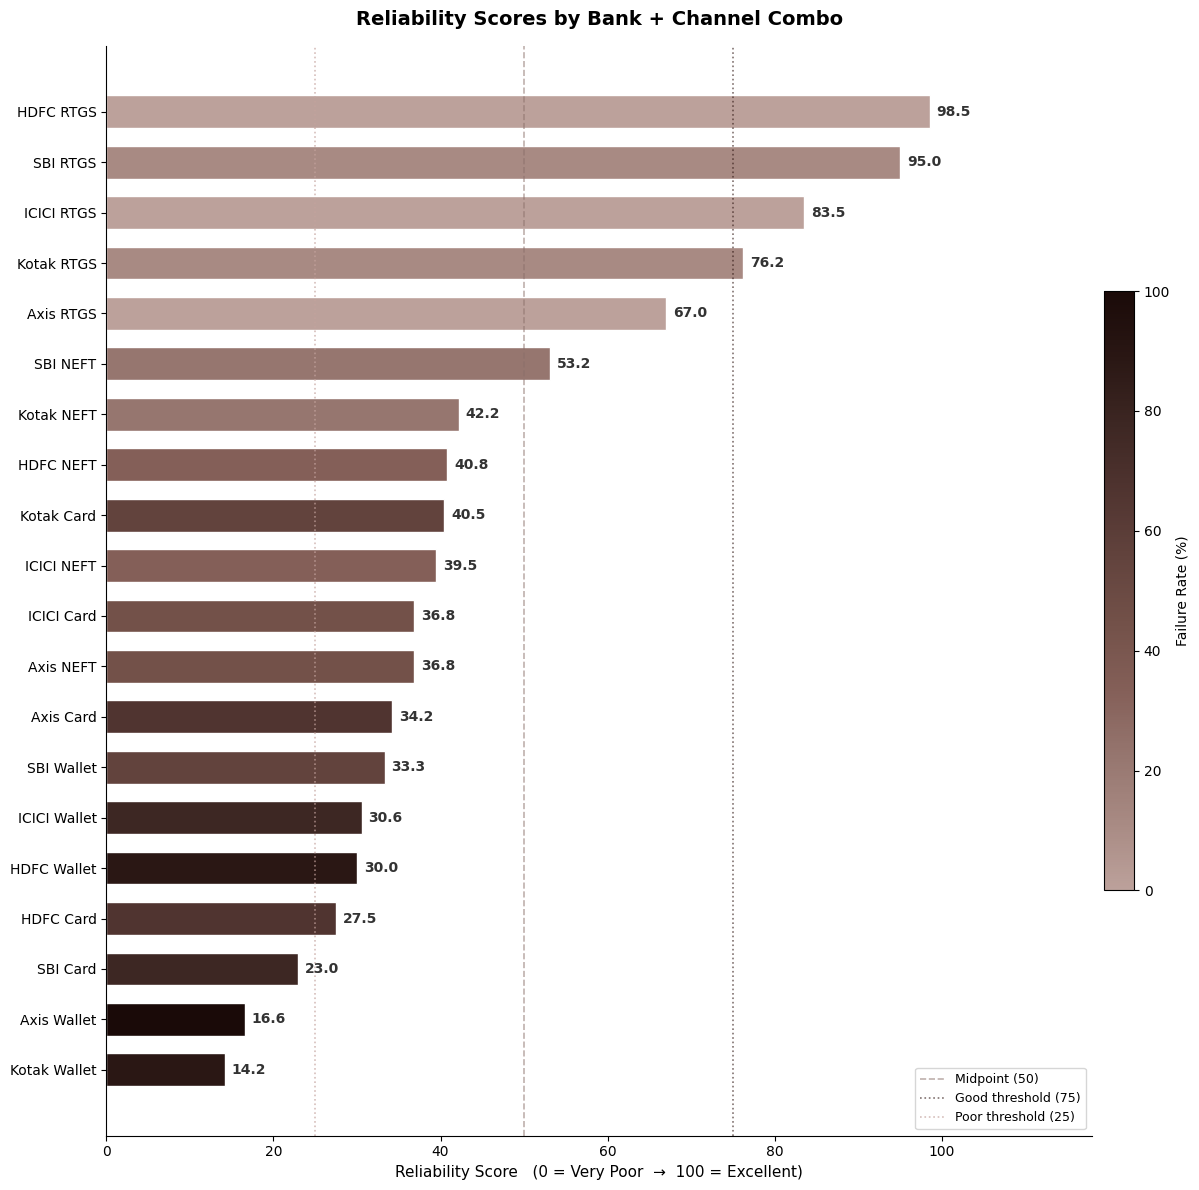

In [53]:
plot_reliability_chart(combo_scores, 'Reliability Scores by Bank + Channel Combo', top_n=20)

RTGS combinations dominate the top with HDFC RTGS (98.5) and SBI RTGS (95.0), while Kotak Wallet (14.2) and Axis Wallet (16.6) are the worst performers.Most Wallet and Card combinations fall below 40, whereas only RTGS consistently crosses the 75 (good threshold).

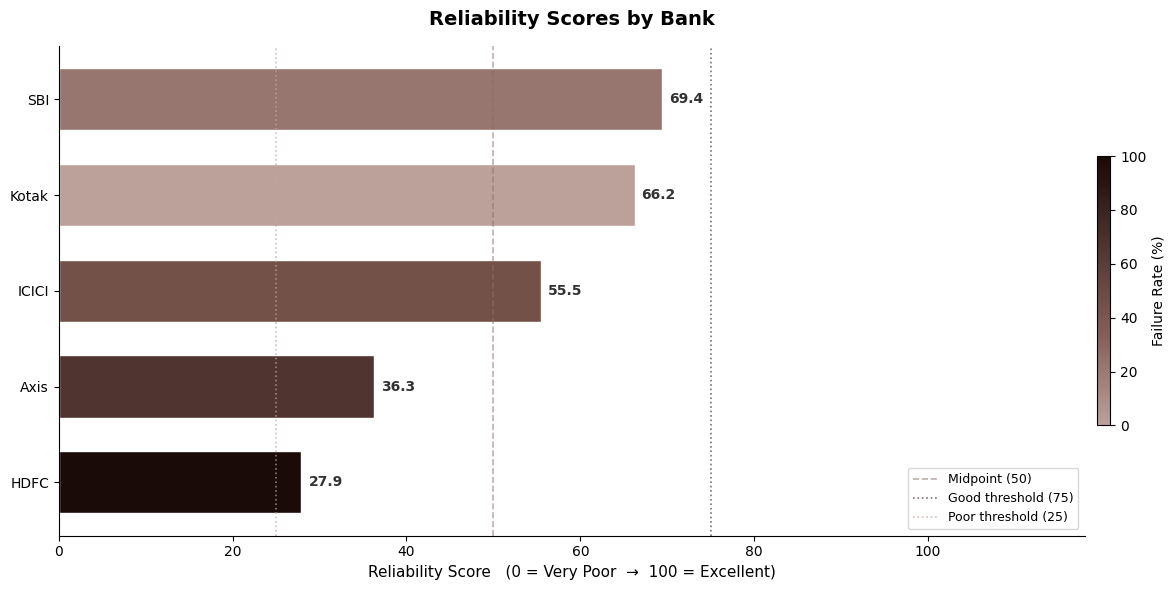

In [52]:
plot_reliability_chart(bank_scores, 'Reliability Scores by Bank', top_n=15)

SBI (69.4) is the most reliable bank, followed by Kotak (66.2) and ICICI (55.5), while HDFC (27.9) ranks the lowest.No bank crosses the 75 threshold, indicating overall moderate reliability at bank level.

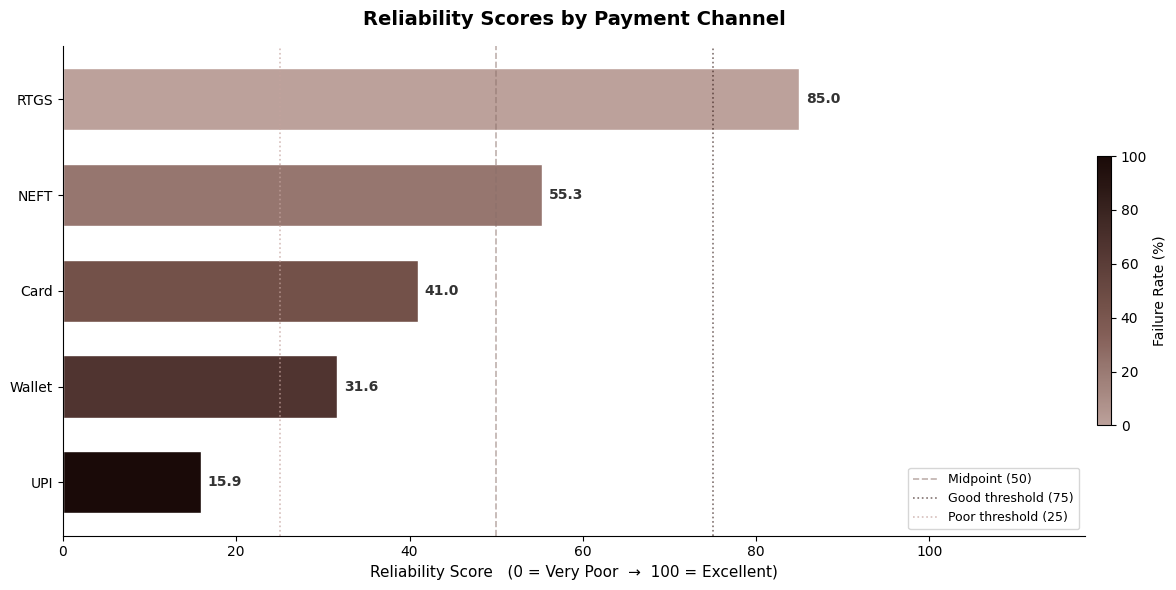

In [51]:
plot_reliability_chart(channel_scores, 'Reliability Scores by Payment Channel')

RTGS (85.0) is the only channel above the good threshold, while UPI (15.9) is the least reliable.NEFT (~55.3) is moderate, whereas Card (~41.0) and Wallet (~31.6) remain below the midpoint (50).

Generate All 3 Charts

Saved → ../data/reliability_channel.png


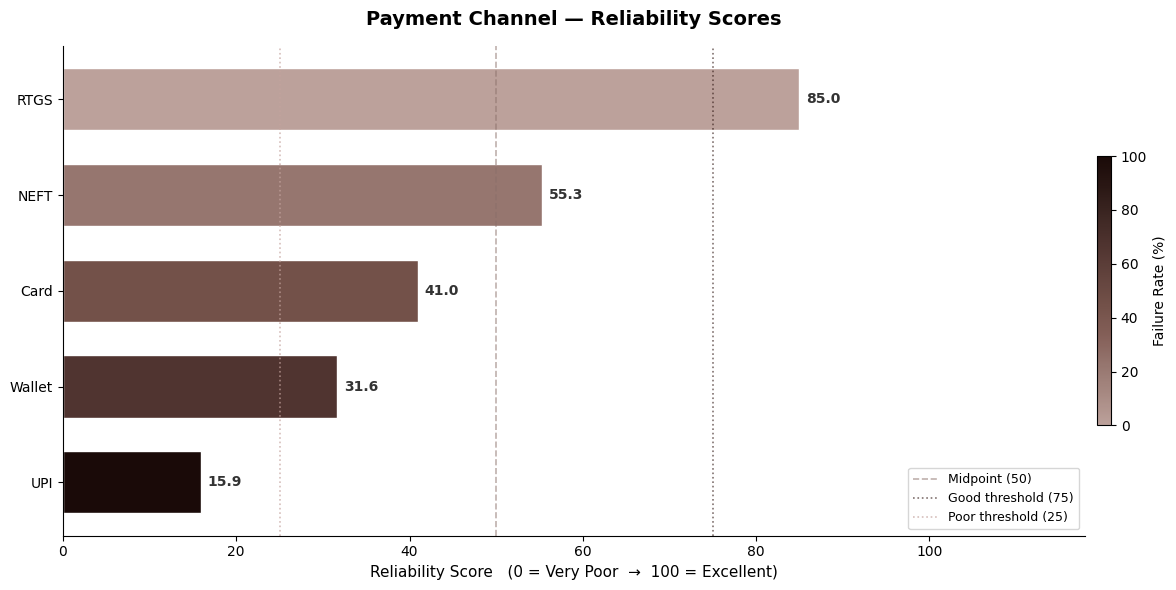

Saved → ../data/reliability_channel.png


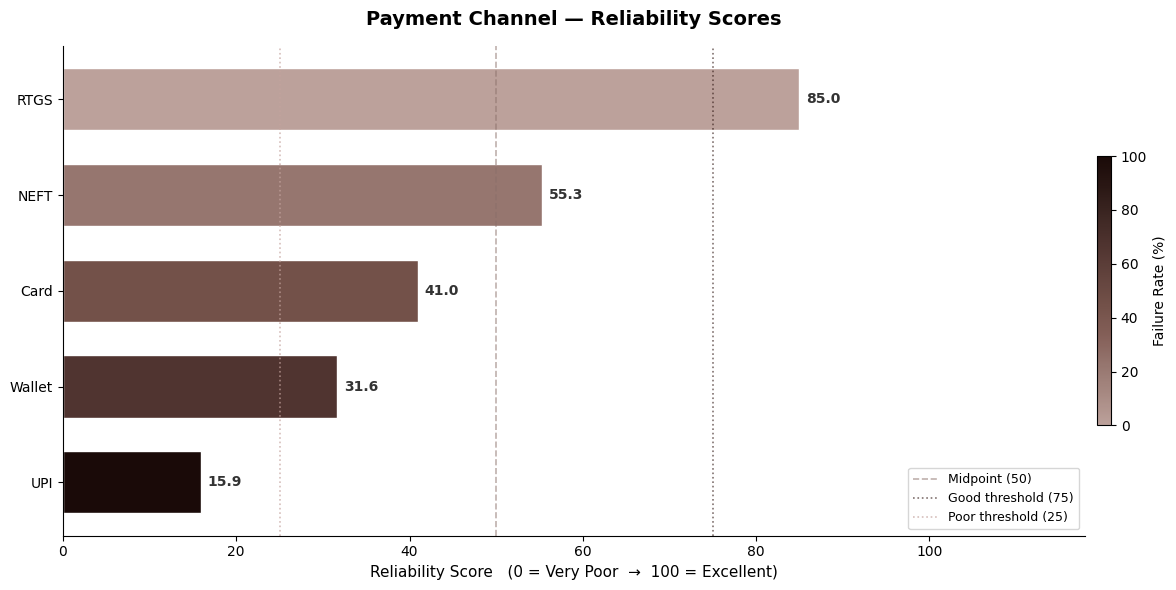

Saved → ../data/reliability_bank.png


Saved → ../data/reliability_channel.png


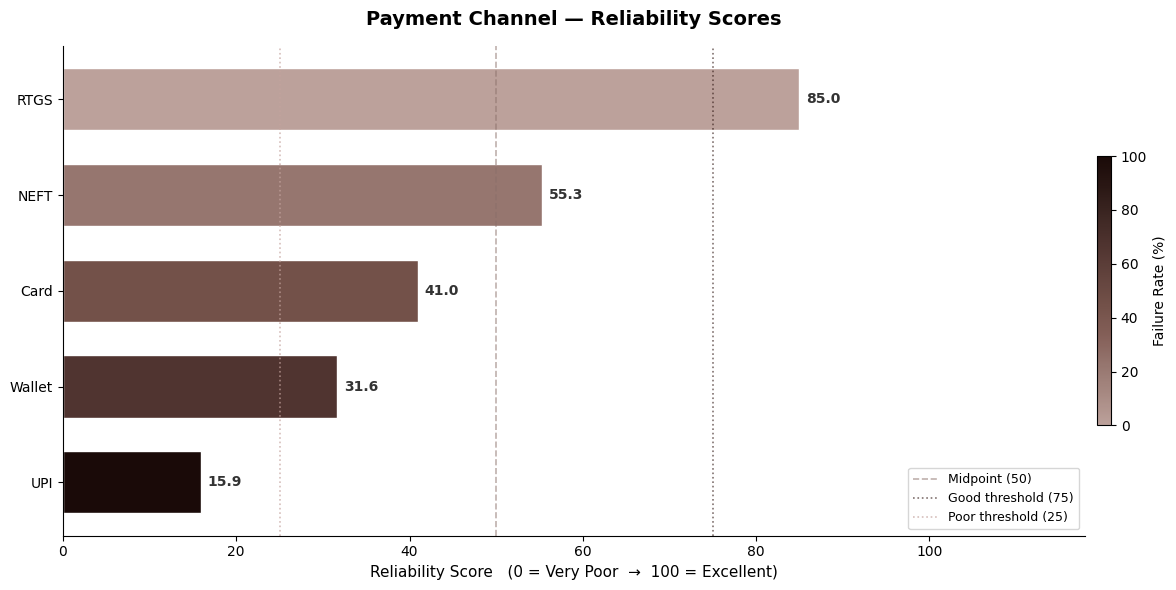

Saved → ../data/reliability_bank.png


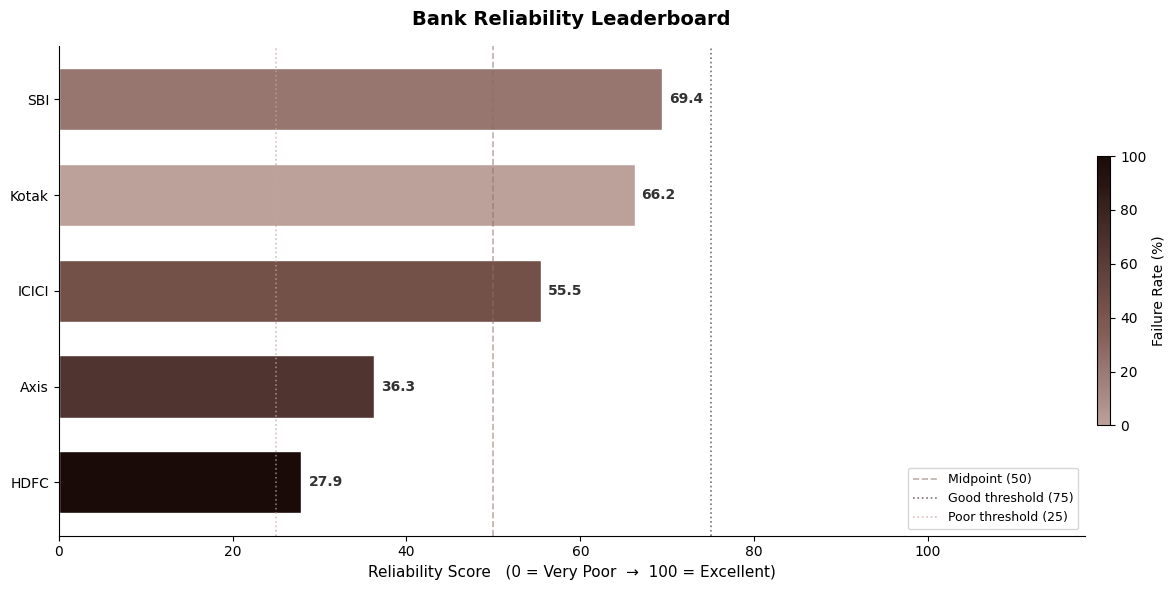

Saved → ../data/reliability_channel.png


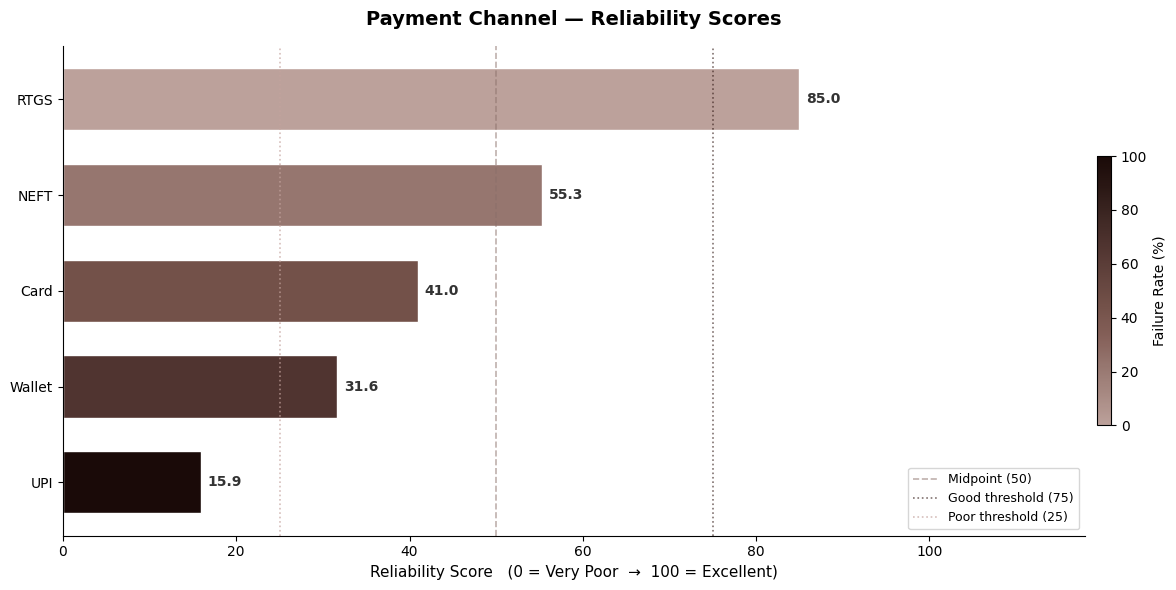

Saved → ../data/reliability_bank.png


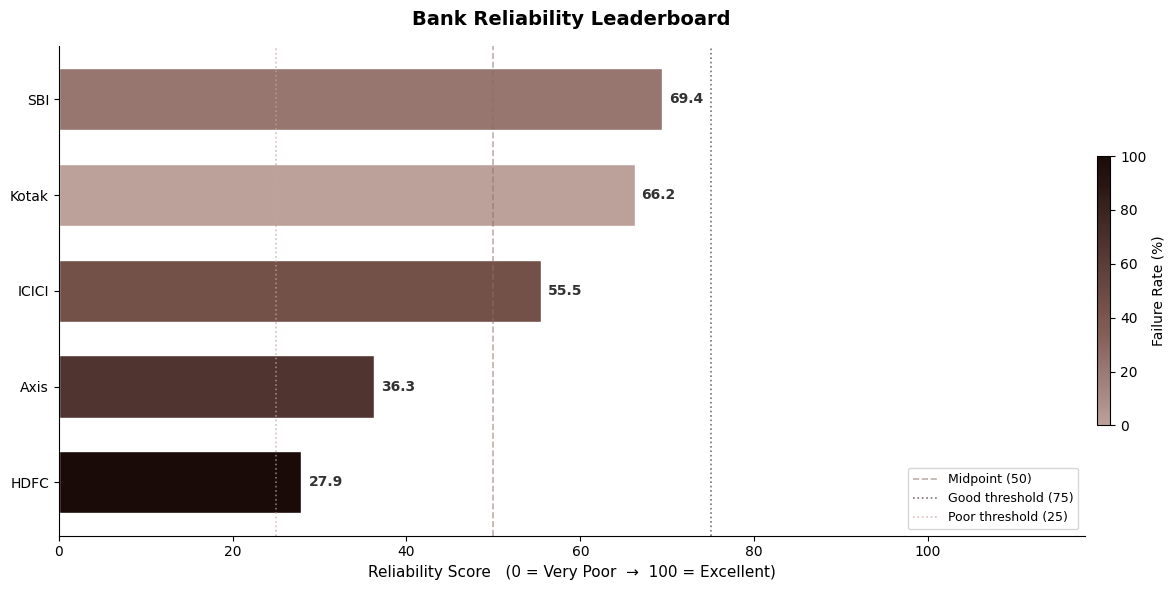

Saved → ../data/reliability_combo.png


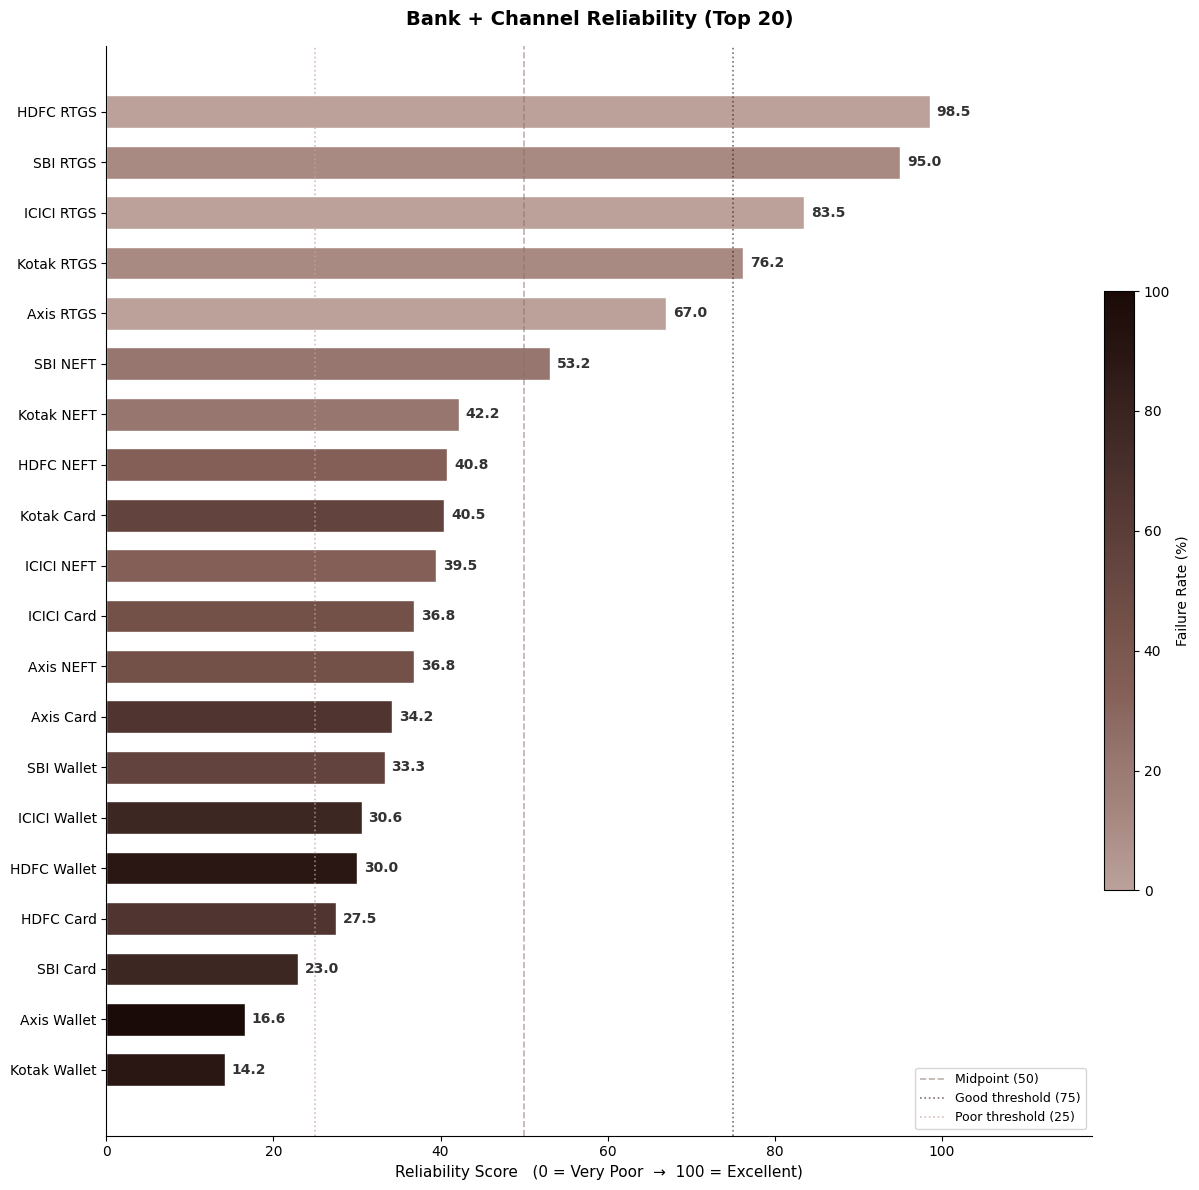

In [54]:
plot_reliability_chart(
    channel_scores,
     'Payment Channel — Reliability Scores',
    save_path='../data/reliability_channel.png'
)

plot_reliability_chart(
    bank_scores,
    'Bank Reliability Leaderboard',
    save_path='../data/reliability_bank.png'
)

plot_reliability_chart(
    combo_scores,
    'Bank + Channel Reliability (Top 20)',
    top_n=20,
    save_path='../data/reliability_combo.png'
)

Payment Channel (Duplicate View): The ranking remains consistent with RTGS (85.0) highest and UPI (15.9) lowest across all channels.A clear gap exists, with RTGS far above others, while Wallet and Card remain below 50.

Bank Leaderboard: SBI (69.4) leads the leaderboard, followed by Kotak (66.2) and ICICI (55.5), while HDFC (27.9) is last.Only the top two banks approach 70, showing no bank achieves high reliability (>75).

Bank + Channel (Top 20 Repeat):Top positions are again held by RTGS combos (HDFC 98.5, SBI 95.0), while lowest include Kotak Wallet (14.2).The chart confirms that channel choice impacts reliability more than bank, with RTGS outperforming all.

Save data/reliability_scores.csv

In [31]:
# Add Group_Type label to each section
ch = channel_scores.reset_index().assign(Group_Type='Channel').rename(columns={'channel':'Group'})
bk = bank_scores.reset_index().assign(Group_Type='Bank').rename(columns={'bank_name':'Group'})
cb = combo_scores.reset_index().assign(Group_Type='Bank+Channel').rename(columns={'bank_channel':'Group'})

leaderboard = pd.concat([ch, bk, cb], ignore_index=True)

# Keep clean column order
leaderboard = leaderboard[[
    'Group_Type', 'Group',
    'Total_Transactions', 'Failed_Transactions', 'Failure_Rate_%',
    'Error_Diversity', 'Avg_Severity',
    'Reliability_Score', 'Rank'
]].sort_values(['Group_Type', 'Reliability_Score'], ascending=[True, False])

leaderboard.to_csv('../data/reliability_scores.csv', index=False)
print(f"✅ Saved → ../data/reliability_scores.csv")
print(f"   Total rows: {len(leaderboard)}")
display(leaderboard.head(25))

✅ Saved → ../data/reliability_scores.csv
   Total rows: 35


,Group_Type,Group,Total_Transactions,Failed_Transactions,Failure_Rate_%,Error_Diversity,Avg_Severity,Reliability_Score,Rank
5,Bank,SBI,2023,461,22.79,10,1.308,69.37,1
6,Bank,Kotak,2005,451,22.49,10,1.344,66.23,2
7,Bank,ICICI,1961,448,22.85,10,1.348,55.48,3
8,Bank,Axis,2030,494,24.33,10,1.283,36.32,4
9,Bank,HDFC,1981,483,24.38,10,1.306,27.92,5
10,Bank+Channel,HDFC RTGS,196,16,8.16,8,1.125,98.55,1
11,Bank+Channel,SBI RTGS,187,20,10.70,8,1.100,95.05,2
12,Bank+Channel,ICICI RTGS,224,20,8.93,9,1.100,83.50,3
13,Bank+Channel,Kotak RTGS,199,18,9.05,9,1.222,76.21,4
14,Bank+Channel,Axis RTGS,204,18,8.82,9,1.389,67.01,5


Final Insights Print

In [32]:
print("=" * 55)
print("           FINAL RELIABILITY INSIGHTS")
print("=" * 55)

best_ch  = channel_scores.index[0]
worst_ch = channel_scores.index[-1]
best_bk  = bank_scores.index[0]
worst_bk = bank_scores.index[-1]
best_cb  = combo_scores.index[0]
worst_cb = combo_scores.index[-1]

print("📡 CHANNEL")
print(f"  Most Reliable  : {best_ch:<15} {channel_scores.loc[best_ch,  'Reliability_Score']}/100")
print(f"  Least Reliable : {worst_ch:<15} {channel_scores.loc[worst_ch, 'Reliability_Score']}/100")

print(f"\n🏦 BANK")
print(f"   ✅ Most Reliable  : {best_bk:<15} {bank_scores.loc[best_bk,  'Reliability_Score']}/100")
print(f"   ❌ Least Reliable : {worst_bk:<15} {bank_scores.loc[worst_bk, 'Reliability_Score']}/100")

print(f"\n🔗 COMBO")
print(f"   ✅ Best  : {best_cb:<20} {combo_scores.loc[best_cb,  'Reliability_Score']}/100")
print(f"   ❌ Worst : {worst_cb:<20} {combo_scores.loc[worst_cb, 'Reliability_Score']}/100")

           FINAL RELIABILITY INSIGHTS
📡 CHANNEL
  Most Reliable  : RTGS            85.0/100
  Least Reliable : UPI             15.92/100

🏦 BANK
   ✅ Most Reliable  : SBI             69.37/100
   ❌ Least Reliable : HDFC            27.92/100

🔗 COMBO
   ✅ Best  : HDFC RTGS            98.55/100
   ❌ Worst : ICICI UPI            2.83/100
